[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/014_clasificacion_binaria/clasificacion_binaria.ipynb)

# **Laboratorio 04 — Regresión Logística Binaria**

En este laboratorio se utiliza el dataset UCI Credit Card para entrenar un modelo de regresión logística binaria. El conjunto contiene 30.000 registros y 25 columnas, incluyendo la variable objetivo relacionada con el incumplimiento del pago.

Se utiliza Pandas para la inspección y preprocesamiento de los datos. Posteriormente se elimina el identificador y se separan las características de la variable objetivo. Los datos se dividen en un 80% para entrenamiento y un 20% para prueba, evitando utilizar los datos de prueba durante el entrenamiento.

Finalmente, se normalizan las características, se calculan los parámetros theta mediante regresión logística y se realizan predicciones sobre los conjuntos de entrenamiento y prueba para evaluar la efectividad del modelo.

# Clasificación Binaria

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize

In [6]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Datasets - sis420 IA/Lab 4/UCI_Credit_Card.csv')

print("Dimensiones del dataset:", df.shape)
print(df.head())

Dimensiones del dataset: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.

In [8]:
# Inspección del dataset utilizando Pandas

print("Información del dataset:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum().sum())

print("\nCantidad de ejemplos por clase:")
print(df["default.payment.next.month"].value_counts())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_A

In [9]:
# Eliminamos ID porque no aporta información para la predicción
# y separamos la variable objetivo

df = df.drop(columns=["ID"])

X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

print("Número de características:", X.shape[1])
print("Número de ejemplos:", X.shape[0])
print("Clases:", y.unique())

Número de características: 23
Número de ejemplos: 30000
Clases: [1 0]


In [10]:
from sklearn.model_selection import train_test_split

# Dividimos los datos en 80% entrenamiento y 20% prueba

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_entrenamiento.shape)
print("Prueba:", X_prueba.shape)

Entrenamiento: (24000, 23)
Prueba: (6000, 23)


In [11]:
# Convertimos los datos a NumPy

X_entrenamiento = X_entrenamiento.to_numpy(dtype=float)
X_prueba = X_prueba.to_numpy(dtype=float)

y_entrenamiento = y_entrenamiento.to_numpy(dtype=float)
y_prueba = y_prueba.to_numpy(dtype=float)

# Normalización utilizando solamente los datos de entrenamiento

mu = np.mean(X_entrenamiento, axis=0)
sigma = np.std(X_entrenamiento, axis=0)

# Evitamos división entre cero
sigma[sigma == 0] = 1

X_entrenamiento = (X_entrenamiento - mu) / sigma
X_prueba = (X_prueba - mu) / sigma

print("Rango aproximado de entrenamiento:")
print(X_entrenamiento.min(), X_entrenamiento.max())

print("\nRango aproximado de prueba:")
print(X_prueba.min(), X_prueba.max())

Rango aproximado de entrenamiento:
-6.37826524030851 59.72533598692915

Rango aproximado de prueba:
-3.328212063884927 82.87243300239487


In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

In [13]:
def lrCostFunction(theta, X, y, lambda_):
    m = len(y)

    h = sigmoid(X.dot(theta))

    epsilon = 1e-5

    J = (-1 / m) * (
        y.dot(np.log(h + epsilon)) +
        (1 - y).dot(np.log(1 - h + epsilon))
    )

    temp = theta.copy()
    temp[0] = 0

    J += (lambda_ / (2 * m)) * np.sum(temp ** 2)

    grad = (1 / m) * X.T.dot(h - y)

    grad += (lambda_ / m) * temp

    return J, grad

In [14]:
# Agregamos la columna de unos para el término de interceptación

m, n = X_entrenamiento.shape

X_entrenamiento_bias = np.concatenate(
    [np.ones((m, 1)), X_entrenamiento],
    axis=1
)

X_prueba_bias = np.concatenate(
    [np.ones((X_prueba.shape[0], 1)), X_prueba],
    axis=1
)

print("X entrenamiento:", X_entrenamiento_bias.shape)
print("X prueba:", X_prueba_bias.shape)

X entrenamiento: (24000, 24)
X prueba: (6000, 24)


In [15]:
# Parámetro de regularización
lambda_ = 0.1

# Inicializamos theta en cero
initial_theta = np.zeros(n + 1)

# Historial del costo
cost_history = []

def cost_function(theta):
    J, grad = lrCostFunction(
        theta,
        X_entrenamiento_bias,
        y_entrenamiento,
        lambda_
    )

    cost_history.append(J)

    return J, grad

# Entrenamiento del modelo

resultado = optimize.minimize(
    cost_function,
    initial_theta,
    jac=True,
    method="CG",
    options={"maxiter": 20}
)

theta = resultado.x

print("Entrenamiento terminado.")
print("Costo final:", resultado.fun)
print("Dimensión de theta:", theta.shape)

Entrenamiento terminado.
Costo final: 0.4632712657933542
Dimensión de theta: (24,)


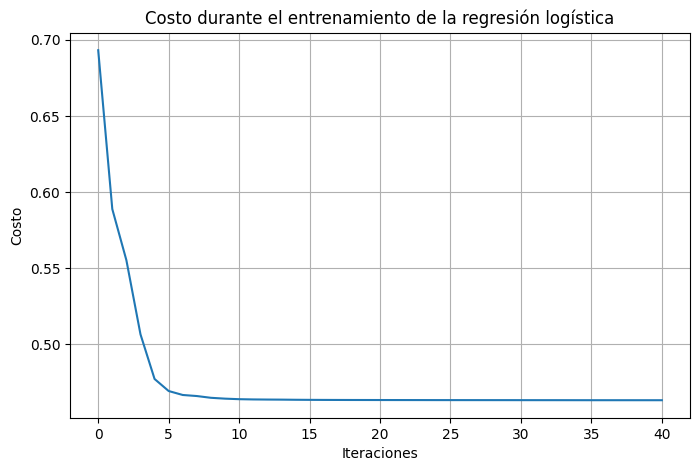

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Costo durante el entrenamiento de la regresión logística")

plt.grid()
plt.show()

In [17]:
def predict(X, theta):
    probabilidades = sigmoid(X.dot(theta))
    predicciones = (probabilidades >= 0.5).astype(int)

    return predicciones

In [18]:
# Predicciones sobre entrenamiento

pred_entrenamiento = predict(
    X_entrenamiento_bias,
    theta
)

precision_entrenamiento = np.mean(
    pred_entrenamiento == y_entrenamiento
) * 100


# Predicciones sobre prueba

pred_prueba = predict(
    X_prueba_bias,
    theta
)

precision_prueba = np.mean(
    pred_prueba == y_prueba
) * 100


print("Precisión sobre entrenamiento: {:.2f}%".format(
    precision_entrenamiento
))

print("Precisión sobre prueba: {:.2f}%".format(
    precision_prueba
))

Precisión sobre entrenamiento: 81.18%
Precisión sobre prueba: 80.83%


Una vez entrenado el modelo, se realizan predicciones tanto sobre los datos de entrenamiento como sobre los datos de prueba. La precisión obtenida permite comparar el comportamiento del modelo frente a datos utilizados durante el aprendizaje y datos que no fueron utilizados para entrenarlo.

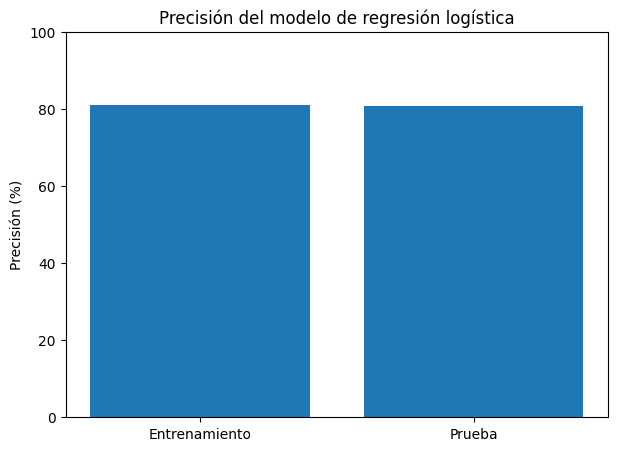

In [19]:
modelos = ["Entrenamiento", "Prueba"]

precisiones = [
    precision_entrenamiento,
    precision_prueba
]

plt.figure(figsize=(7, 5))

plt.bar(modelos, precisiones)

plt.ylabel("Precisión (%)")
plt.title("Precisión del modelo de regresión logística")
plt.ylim(0, 100)

plt.show()